<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 8 to 3
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  120 non-null    float64
 1   sepal width (cm)   120 non-null    float64
 2   petal length (cm)  120 non-null    float64
 3   petal width (cm)   120 non-null    float64
dtypes: float64(4)
memory usage: 4.7 KB
None


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [4]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Acurácia de Treino
train_accuracy = model.score(X_train, y_train)
print(train_accuracy)

1.0


In [5]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

# Acurácia de Teste
test_accuracy = accuracy_score(y_test, predictions)
print(test_accuracy)

0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

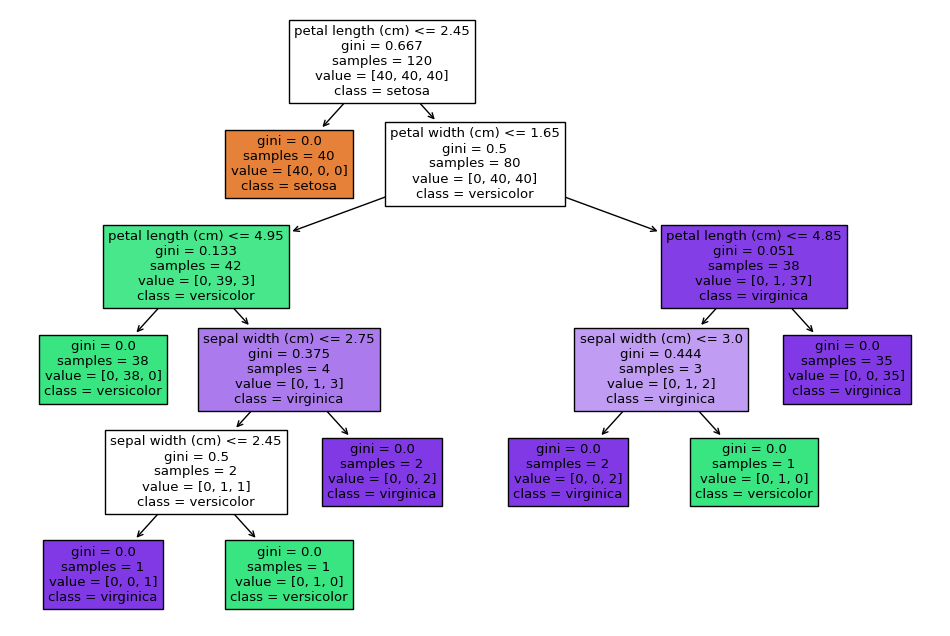

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
	model,
	feature_names=X.columns,
	class_names=iris.target_names,
	filled=True)

plt.show()

1. Petal Length
2. 5

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [7]:
for i in range(1, 11):
	if i == 10:
		model = DecisionTreeClassifier(max_depth=None)
		max_depth = "None"
	else:
		model = DecisionTreeClassifier(max_depth=i)
		max_depth = i

	model.fit(X_train, y_train)

	train_accuracy = model.score(X_train, y_train)

	predictions = model.predict(X_test)
	test_accuracy = accuracy_score(y_test, predictions)

	tree_depth = model.get_depth()
	num_leaves = model.get_n_leaves()

	print(f"Max Depth: {max_depth} | Acurácia de Treino: {train_accuracy:.3f} | Acurácia de Teste: {test_accuracy:.3f} | Profundidade: {tree_depth} | Número de Folhas: {num_leaves}")


Max Depth: 1 | Acurácia de Treino: 0.667 | Acurácia de Teste: 0.667 | Profundidade: 1 | Número de Folhas: 2
Max Depth: 2 | Acurácia de Treino: 0.967 | Acurácia de Teste: 0.933 | Profundidade: 2 | Número de Folhas: 3
Max Depth: 3 | Acurácia de Treino: 0.983 | Acurácia de Teste: 0.967 | Profundidade: 3 | Número de Folhas: 5
Max Depth: 4 | Acurácia de Treino: 0.992 | Acurácia de Teste: 0.967 | Profundidade: 4 | Número de Folhas: 7
Max Depth: 5 | Acurácia de Treino: 1.000 | Acurácia de Teste: 0.967 | Profundidade: 5 | Número de Folhas: 8
Max Depth: 6 | Acurácia de Treino: 1.000 | Acurácia de Teste: 0.933 | Profundidade: 5 | Número de Folhas: 8
Max Depth: 7 | Acurácia de Treino: 1.000 | Acurácia de Teste: 0.967 | Profundidade: 5 | Número de Folhas: 8
Max Depth: 8 | Acurácia de Treino: 1.000 | Acurácia de Teste: 0.967 | Profundidade: 5 | Número de Folhas: 8
Max Depth: 9 | Acurácia de Treino: 1.000 | Acurácia de Teste: 0.933 | Profundidade: 5 | Número de Folhas: 8
Max Depth: None | Acurácia d

**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

1. O overfitting começa ao redor de max_depth = 3 ou 4, uma vez que depois disso a acurácia de teste não melhora porem a acurácia de treino aumenta até 100%, demostrando um super ajuste aos dados de treino.
2. Pois quando max_depth = None, a árvore "cresce" até que todas as folhas sejam puras, ou seja, que não haja "dúvida" nas classificações, sempre que o modelo chegar em uma folha a classificação feita terá "certeza".

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [8]:
for i in range(2):
	if i == 0:
		model = DecisionTreeClassifier(criterion="gini")
	else:
		model = DecisionTreeClassifier(criterion="entropy")

	model.fit(X_train, y_train)

	train_accuracy = model.score(X_train, y_train)

	predictions = model.predict(X_test)
	test_accuracy = accuracy_score(y_test, predictions)

	tree_depth = model.get_depth()

	print(f"Acurácia de Treino: {train_accuracy:.3f} | Acurácia de Teste: {test_accuracy:.3f} | Profundidade: {tree_depth}")

Acurácia de Treino: 1.000 | Acurácia de Teste: 0.967 | Profundidade: 5
Acurácia de Treino: 1.000 | Acurácia de Teste: 0.967 | Profundidade: 5


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [9]:
for i in range(1, 11):
	
	model = DecisionTreeClassifier(min_samples_leaf=i)
	min_samples_leaf = i

	model.fit(X_train, y_train)

	train_accuracy = model.score(X_train, y_train)

	predictions = model.predict(X_test)
	test_accuracy = accuracy_score(y_test, predictions)

	tree_depth = model.get_depth()
	num_leaves = model.get_n_leaves()

	print(f"Min Samples Leaf: {min_samples_leaf} | Acurácia de Treino: {train_accuracy:.3f} | Acurácia de Teste: {test_accuracy:.3f} | Profundidade: {tree_depth} | Número de Folhas: {num_leaves}")


Min Samples Leaf: 1 | Acurácia de Treino: 1.000 | Acurácia de Teste: 0.933 | Profundidade: 5 | Número de Folhas: 8
Min Samples Leaf: 2 | Acurácia de Treino: 0.983 | Acurácia de Teste: 0.933 | Profundidade: 4 | Número de Folhas: 6
Min Samples Leaf: 3 | Acurácia de Treino: 0.983 | Acurácia de Teste: 0.967 | Profundidade: 3 | Número de Folhas: 5
Min Samples Leaf: 4 | Acurácia de Treino: 0.983 | Acurácia de Teste: 0.967 | Profundidade: 3 | Número de Folhas: 5
Min Samples Leaf: 5 | Acurácia de Treino: 0.967 | Acurácia de Teste: 0.933 | Profundidade: 3 | Número de Folhas: 5
Min Samples Leaf: 6 | Acurácia de Treino: 0.967 | Acurácia de Teste: 0.933 | Profundidade: 3 | Número de Folhas: 5
Min Samples Leaf: 7 | Acurácia de Treino: 0.967 | Acurácia de Teste: 0.933 | Profundidade: 3 | Número de Folhas: 5
Min Samples Leaf: 8 | Acurácia de Treino: 0.967 | Acurácia de Teste: 0.933 | Profundidade: 3 | Número de Folhas: 5
Min Samples Leaf: 9 | Acurácia de Treino: 0.967 | Acurácia de Teste: 0.933 | Pro

O melhor modelo aparenta ser o que utiliza min_samples_leaf entre 3 e 4, uma vez que equilibram o menor valor de acurácia de treino com o maior valor de acurácia de teste, contendo o "melhor dos dois mundos".